## 1. IMPORT

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

## 2. ĐỌC DỮ LIỆU

In [2]:
df_success = pd.read_csv('../data/df_success.csv')
df_success['InvoiceDate'] = pd.to_datetime(df_success['InvoiceDate'])

## 3. TÍNH RFM

In [3]:
now = df_success['InvoiceDate'].max() + pd.Timedelta(days=1)

customer = df_success.groupby('Customer ID').agg({
    'Country': 'first',
    'InvoiceDate': lambda x: (now - x.max()).days,
    'Amount': 'sum',
    'Invoice': 'nunique'
}).rename(columns={
    'InvoiceDate': 'Recency',
    'Amount': 'Monetary',
    'Invoice': 'Frequency'
})

print(f"Total customers: {len(customer)}")
print(f"\nRFM Statistics:")
print(customer[['Recency', 'Monetary', 'Frequency']].describe())

Total customers: 4314

RFM Statistics:
           Recency       Monetary    Frequency
count  4314.000000    4314.000000  4314.000000
mean     91.269124    2047.288659     4.454103
std      96.943482    8912.523243     8.168658
min       1.000000       0.000000     1.000000
25%      18.000000     307.950000     1.000000
50%      53.000000     705.550000     2.000000
75%     136.000000    1722.802500     5.000000
max     374.000000  349164.350000   205.000000


## 4. TÁCH SIÊU VIP (OUTLIER) TRƯỚC KHI PHÂN CỤM

In [4]:
Q1 = customer['Monetary'].quantile(0.25)
Q3 = customer['Monetary'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR   

customer['Is_Outlier'] = customer['Monetary'] > upper_bound

print(f"Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")
print(f"Upper bound = {upper_bound:.2f}")
print(f"Super VIP customers: {customer['Is_Outlier'].sum()} ({customer['Is_Outlier'].mean()*100:.1f}%)")
print(f"Normal customers: {(~customer['Is_Outlier']).sum()} ({(~customer['Is_Outlier']).mean()*100:.1f}%)")

Q1=307.95, Q3=1722.80, IQR=1414.85
Upper bound = 3845.08
Super VIP customers: 428 (9.9%)
Normal customers: 3886 (90.1%)


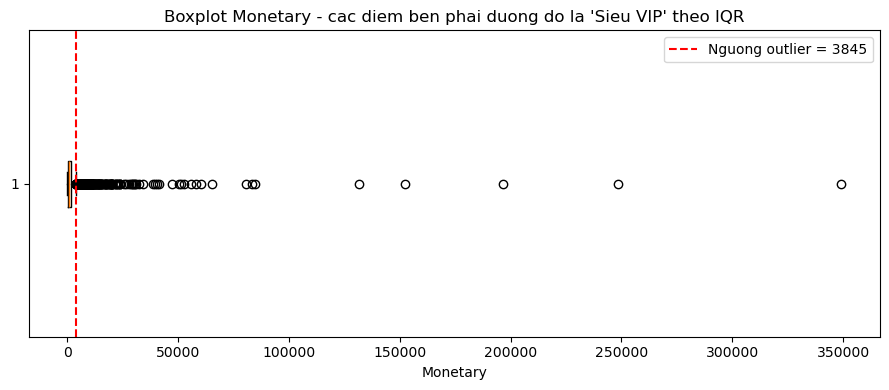

In [5]:
plt.figure(figsize=(9,4))
plt.boxplot(customer['Monetary'], vert=False)
plt.axvline(upper_bound, color='red', linestyle='--', label=f'Nguong outlier = {upper_bound:.0f}')
plt.title("Boxplot Monetary - cac diem ben phai duong do la 'Sieu VIP' theo IQR")
plt.xlabel('Monetary')
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
vip = customer[customer['Is_Outlier']].copy()
normal = customer[~customer['Is_Outlier']].copy()

vip['Segment'] = 'Champions'
vip['Cluster'] = -1  # danh dau: khong thuoc KMeans, tach rieng bang threshold

print("Super VIP group quick stats:")
print(vip[['Recency','Monetary','Frequency']].agg(['mean','median']).round(2))

Super VIP group quick stats:
        Recency  Monetary  Frequency
mean      30.88  12319.51      17.28
median    14.00   6262.58      12.00


## 5. XỬ LÝ DỮ LIỆU CHO CLUSTERING (chỉ trên phần `normal`)

In [7]:
rfm_log = normal.copy()
rfm_log['Recency'] = np.log1p(rfm_log['Recency'])
rfm_log['Monetary'] = np.log1p(rfm_log['Monetary'])
rfm_log['Frequency'] = np.log1p(rfm_log['Frequency'])

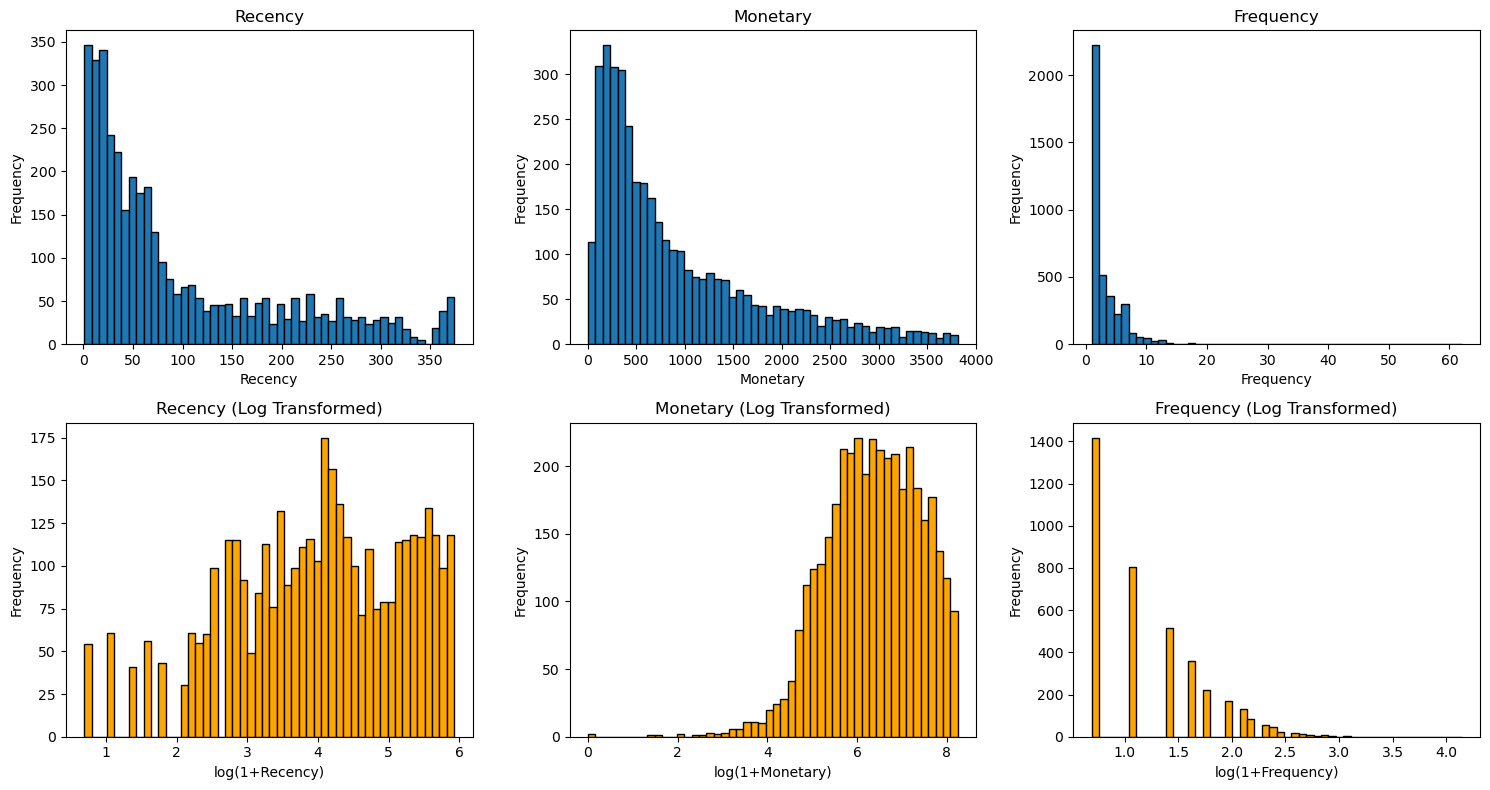

In [8]:
# Visualize phan phoi truoc va sau log (tren phan normal)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
features = ['Recency', 'Monetary', 'Frequency']

for i, feature in enumerate(features):
    axes[0, i].hist(normal[feature], bins=50, edgecolor='black')
    axes[0, i].set_title(f'{feature}')
    axes[0, i].set_xlabel(feature)
    axes[0, i].set_ylabel('Frequency')

    axes[1, i].hist(rfm_log[feature], bins=50, edgecolor='black', color='orange')
    axes[1, i].set_title(f'{feature} (Log Transformed)')
    axes[1, i].set_xlabel(f'log(1+{feature})')
    axes[1, i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [9]:
# scaler
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log[['Recency', 'Monetary', 'Frequency']])
rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=['Recency', 'Monetary', 'Frequency'],
    index=rfm_log.index
)

## 6. TÌM K TỐI ƯU 

In [10]:
K_range = range(2, 11)
wcss = []
silhouette_scores = []
davies_bouldin_scores = []
calinski_harabasz_scores = []

for k in K_range:
    kmeans_tmp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans_tmp.fit_predict(rfm_scaled)

    wcss.append(kmeans_tmp.inertia_)
    silhouette_scores.append(silhouette_score(rfm_scaled, labels))
    davies_bouldin_scores.append(davies_bouldin_score(rfm_scaled, labels))
    calinski_harabasz_scores.append(calinski_harabasz_score(rfm_scaled, labels))

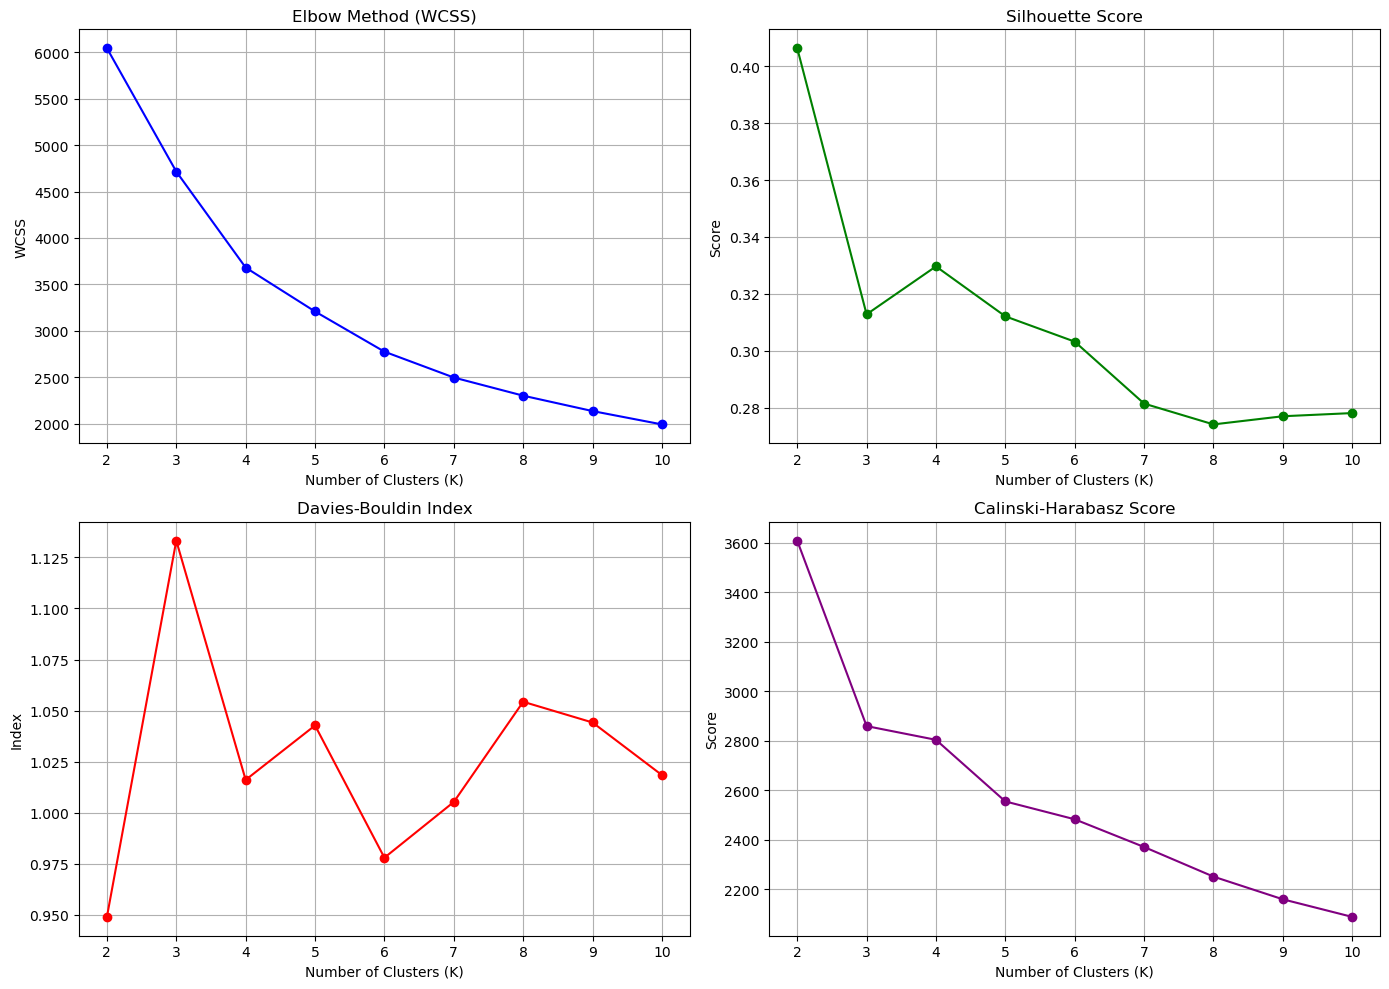

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(K_range, wcss, marker='o', color='blue')
axes[0, 0].set_title('Elbow Method (WCSS)')
axes[0, 0].set_xlabel('Number of Clusters (K)')
axes[0, 0].set_ylabel('WCSS')
axes[0, 0].grid(True)

axes[0, 1].plot(K_range, silhouette_scores, marker='o', color='green')
axes[0, 1].set_title('Silhouette Score')
axes[0, 1].set_xlabel('Number of Clusters (K)')
axes[0, 1].set_ylabel('Score')
axes[0, 1].grid(True)

axes[1, 0].plot(K_range, davies_bouldin_scores, marker='o', color='red')
axes[1, 0].set_title('Davies-Bouldin Index')
axes[1, 0].set_xlabel('Number of Clusters (K)')
axes[1, 0].set_ylabel('Index')
axes[1, 0].grid(True)

axes[1, 1].plot(K_range, calinski_harabasz_scores, marker='o', color='purple')
axes[1, 1].set_title('Calinski-Harabasz Score')
axes[1, 1].set_xlabel('Number of Clusters (K)')
axes[1, 1].set_ylabel('Score')
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

## 7. CHỌN K DỰA TRÊN METRIC

In [12]:
metric_df = pd.DataFrame({
    'K': list(K_range),
    'WCSS': wcss,
    'Silhouette': silhouette_scores,
    'Davies-Bouldin': davies_bouldin_scores,
    'Calinski-Harabasz': calinski_harabasz_scores
})
print("Bảng tổng hợp các metrics:")
print(metric_df.round(4))

optimal_k = 3

Bảng tổng hợp các metrics:
    K       WCSS  Silhouette  Davies-Bouldin  Calinski-Harabasz
0   2  6043.2341      0.4063          0.9490          3608.6326
1   3  4714.9377      0.3128          1.1332          2859.0705
2   4  3681.5763      0.3297          1.0161          2803.5831
3   5  3209.0152      0.3121          1.0427          2554.5810
4   6  2776.4369      0.3032          0.9780          2482.3988
5   7  2498.2340      0.2815          1.0052          2370.4031
6   8  2302.7996      0.2742          1.0543          2250.6783
7   9  2137.1309      0.2770          1.0442          2158.9965
8  10  1993.5822      0.2782          1.0184          2087.8504


## 8. PHÂN CỤM VỚI K TỐI ƯU (trên `normal`)

In [13]:
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm_scaled['Cluster'] = kmeans.fit_predict(rfm_scaled[['Recency', 'Monetary', 'Frequency']])
normal['Cluster'] = rfm_scaled['Cluster']

## 9. PHÂN TÍCH ĐẶC ĐIỂM TỪNG CLUSTER

In [14]:
cluster_summary_scaled = rfm_scaled.groupby('Cluster')[['Recency', 'Monetary', 'Frequency']].mean()
print("Đặc điểm các cluster (dữ liệu đã chuẩn hóa):")
print(cluster_summary_scaled.round(4))

cluster_summary_original = normal.groupby('Cluster')[['Recency', 'Monetary', 'Frequency']].agg(['mean', 'median'])
print("\nĐặc điểm các cluster (dữ liệu gốc):")
print(cluster_summary_original.round(2))

Đặc điểm các cluster (dữ liệu đã chuẩn hóa):
         Recency  Monetary  Frequency
Cluster                              
0         0.0349    0.3616     0.0891
1         0.5927   -0.9545    -0.8816
2        -1.0666    1.0347     1.3560

Đặc điểm các cluster (dữ liệu gốc):
        Recency        Monetary          Frequency       
           mean median     mean   median      mean median
Cluster                                                  
0         80.23   59.0   989.77   806.44      2.78    3.0
1        159.52  148.0   255.85   231.34      1.18    1.0
2         21.91   15.0  1919.42  1849.20      6.64    6.0


## 10. GÁN NHÃN PHÂN KHÚC

In [15]:
def assign_segment(cluster_id):
    # Sắp xếp giảm dần theo Monetary
    sorted_clusters = cluster_summary_scaled.sort_values('Monetary', ascending=False).index.tolist()

    if cluster_id == sorted_clusters[0]:
        return 'Loyalists'
    elif cluster_id == sorted_clusters[-1]:
        return 'Need Attention'
    else:
        return 'High-Potential'

normal['Segment'] = normal['Cluster'].apply(assign_segment)

# Ghép vip và normal
customer = pd.concat([vip, normal])
print(customer['Segment'].value_counts())

Segment
Need Attention    1526
High-Potential    1464
Loyalists          896
Champions          428
Name: count, dtype: int64


## 11. TRỰC QUAN HÓA KẾT QUẢ PCA (trên `normal`, không lẫn Champions)

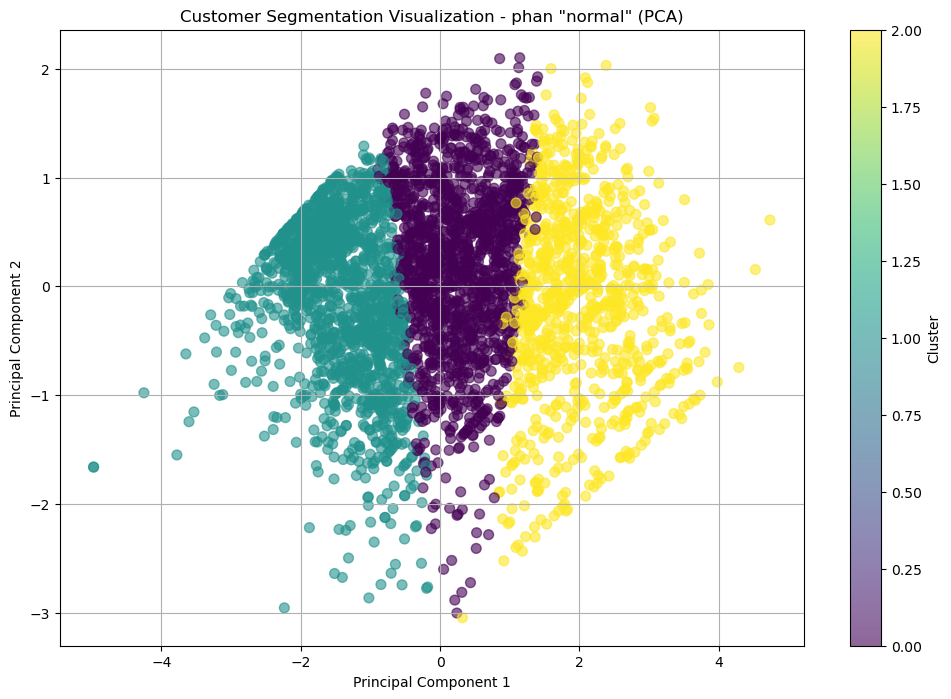

In [16]:
pca = PCA(n_components=2)
rfm_pca = pca.fit_transform(rfm_scaled[['Recency', 'Monetary', 'Frequency']])
rfm_scaled['PCA1'] = rfm_pca[:, 0]
rfm_scaled['PCA2'] = rfm_pca[:, 1]

plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    rfm_scaled['PCA1'],
    rfm_scaled['PCA2'],
    c=rfm_scaled['Cluster'],
    cmap='viridis',
    alpha=0.6,
    s=50
)
plt.title('Customer Segmentation Visualization - phan "normal" (PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(scatter, label='Cluster')
plt.grid(True)
plt.show()

## 12. PHÂN BỔ KHÁCH HÀNG THEO TỪNG SEGMENT (toàn bộ, gồm cả Champions)

PHÂN PHỐI KHÁCH HÀNG THEO SEGMENT:
Segment
Need Attention    1526
High-Potential    1464
Loyalists          896
Champions          428
Name: count, dtype: int64

Tỷ lệ phần trăm:
Segment
Need Attention    35.4
High-Potential    33.9
Loyalists         20.8
Champions          9.9
Name: count, dtype: float64


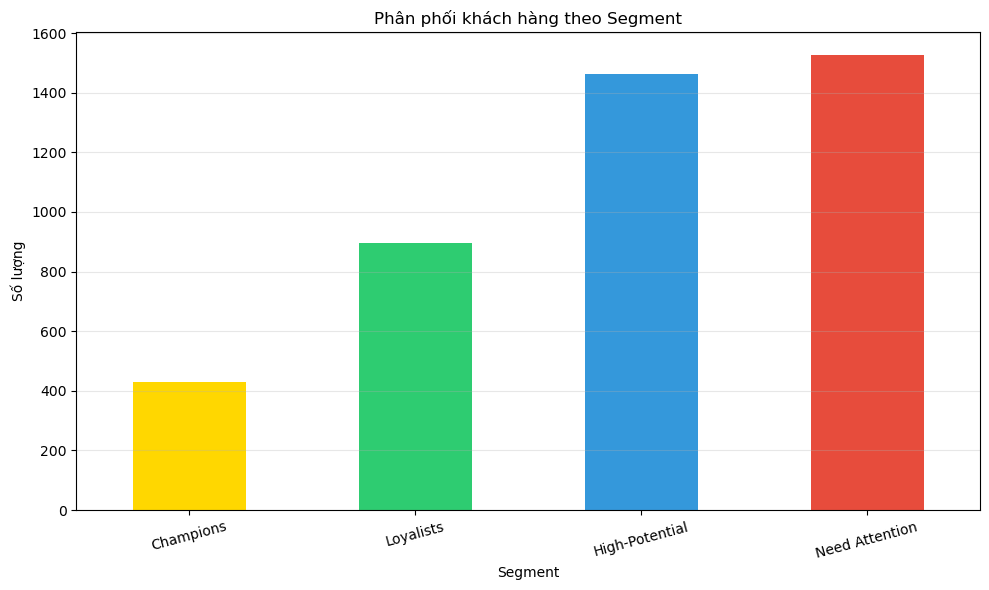

In [17]:
segment_counts = customer['Segment'].value_counts()
print("PHÂN PHỐI KHÁCH HÀNG THEO SEGMENT:")
print(segment_counts)
print("\nTỷ lệ phần trăm:")
print((segment_counts / len(customer) * 100).round(1))

order = ['Champions', 'Loyalists', 'High-Potential', 'Need Attention']
plt.figure(figsize=(10, 6))
segment_counts.reindex(order).plot(kind='bar', color=['#FFD700', '#2ECC71', '#3498DB', '#E74C3C'])
plt.title('Phân phối khách hàng theo Segment')
plt.xlabel('Segment')
plt.ylabel('Số lượng')
plt.xticks(rotation=15)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 13. CHI TIẾT TỪNG SEGMENT

In [18]:
segment_profile = customer.groupby('Segment')[['Recency', 'Monetary', 'Frequency']].agg(['mean', 'median', 'std'])
print("ĐẶC ĐIỂM CHI TIẾT TỪNG SEGMENT:")
print(segment_profile.round(2))

ĐẶC ĐIỂM CHI TIẾT TỪNG SEGMENT:
               Recency                 Monetary                    Frequency  \
                  mean median     std      mean   median       std      mean   
Segment                                                                        
Champions        30.88   14.0   49.23  12319.51  6262.58  26044.46     17.28   
High-Potential   80.23   59.0   69.17    989.77   806.44    615.01      2.78   
Loyalists        21.91   15.0   23.39   1919.42  1849.20    856.13      6.64   
Need Attention  159.52  148.0  111.18    255.85   231.34    149.88      1.18   

                              
               median    std  
Segment                       
Champions        12.0  20.49  
High-Potential    3.0   1.21  
Loyalists         6.0   3.50  
Need Attention    1.0   0.42  


## 14. EXPORT MODEL & KẾT QUẢ

In [19]:
customer.to_csv('../data/customer_segmented.csv', index=True)
print("Đã lưu file 'customer_segmented.csv'")

import joblib
model_artifacts = {
    'scaler': scaler,
    'kmeans': kmeans,
    'pca': pca,
    'outlier_threshold': upper_bound,    
    'segment_mapping': {
        **dict(zip(range(optimal_k), normal.groupby('Cluster')['Segment'].first().reindex(range(optimal_k)).values)),
        'outlier': 'Champions'
    }
}
joblib.dump(model_artifacts, '../models/clustering_model.pkl')
print("Đã lưu model 'clustering_model.pkl'")

Đã lưu file 'customer_segmented.csv'
Đã lưu model 'clustering_model.pkl'


## 15. TOP KHÁCH HÀNG

In [20]:
top_customers = customer.nlargest(5, 'Monetary')
print("TOP 5 KHÁCH HÀNG THEO MONETARY:")
print(top_customers[['Recency', 'Monetary', 'Frequency', 'Segment']])

TOP 5 KHÁCH HÀNG THEO MONETARY:
             Recency   Monetary  Frequency    Segment
Customer ID                                          
18102.0            1  349164.35         89  Champions
14646.0           10  248396.50         78  Champions
14156.0            7  196566.74        102  Champions
14911.0            1  152147.57        205  Champions
13694.0            9  131443.19         94  Champions
